In [1]:
%load_ext cuml.accel
# %run /workspace/alvin/SAR_ML/notebooks/SSR/SSRtransforms_preloaded.py
%run /mnt/d/Users/Admin/Projects/dso/SAR_ML/notebooks/SSR/SSRtransforms_preloaded.py
import os
import random
from collections import defaultdict
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, ConcatDataset, Subset, Dataset
import re
import copy
import torchvision
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from cuml.manifold import TSNE, UMAP
from joblib import Parallel, delayed
from tqdm import tqdm
from scipy.integrate import trapezoid

In [2]:
def set_seed(seed=42):
    """Set all random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # Uncomment only if you need 100% determinism and can handle errors
    # torch.use_deterministic_algorithms(True, warn_only=True)
    # os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
    
    os.environ["PYTHONHASHSEED"] = str(seed)

def worker_init_fn(worker_id):
    """DataLoader worker init for reproducibility"""
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

In [3]:
# workspace = "/workspace/alvin/SAR_ML"
workspace = "/mnt/d/Users/Admin/Projects/dso/SAR_ML"
data_workspace = os.path.join(workspace, "data/SAMPLE")

# SSR w noise

In [4]:
gmm_cache = build_gmm_cache(input_dir = os.path.join(data_workspace, "mat_files/synth"), processing_func = LogMapping(c = 1000.0))

Found 1345 .mat files


Fitting GMMs: 100%|██████████| 1345/1345 [02:44<00:00,  8.20it/s]


In [5]:
synth_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/synth"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), SSRAugmentation(gmm_cache, alpha=0.6, beta=0.4, apply_prob=0.5, gaussian_noise = True, mu_s = 0.0, sigma_s = 0.3), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

meas_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

In [6]:
label_full = []
prob_full = []
pred_og_full = []

for j in range(10):
    
    excluded_label = j
    excluded_label_name = synth_ds.classes[excluded_label]
    print(f"Excluding label {excluded_label} ({excluded_label_name}) from synthetic dataset")
    new_synth_ds = RemappedSubset(synth_ds, exclude_label=excluded_label)

    train_ds = new_synth_ds
    test_ds = meas_ds

    seed_lst = [42]

    label_lst = []
    prob_lst = []
    pred_lst = []

    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    for i, seed in enumerate(seed_lst):
        print(f"Evaluating Run {i}: seed {seed}")
        new_model = models.resnet18(weights = None) # dont load ImageNet Weights
        new_model.fc = nn.Sequential(
            nn.Dropout(p = 0.4),
            nn.Linear(new_model.fc.in_features, len(synth_ds.class_to_idx) - 1)
        )
        
        # Load your trained weights
        new_model.load_state_dict(torch.load(
            os.path.join(workspace, f"weights/SSR/OOD/SSR_w_noise/rn18_seed{seed}_b16_rm_{excluded_label_name}.pth"),
            map_location=device
        ))
        
        new_model = new_model.to(device)
        new_model.eval()
        
        with torch.no_grad():
            for inputs, labels in DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=12, pin_memory=True, persistent_workers=True):
                inputs = inputs.to(device)
        
                outputs = new_model(inputs)
                probs = F.softmax(outputs, dim=1)
                confidence, preds = torch.max(probs, dim=1)
        
                prob_lst.append(confidence.cpu())
                pred_lst.append(preds.cpu())
                label_lst.append(labels)  # already on cpu from dataloader

    inv_label_map = {v: k for k, v in new_synth_ds.label_map.items()}

    preds_og = [
        inv_label_map[p.item()] for p in torch.cat(pred_lst)
    ]

    label_full.append(label_lst)
    prob_full.append(prob_lst)
    pred_og_full.append(preds_og)

label_full_flat = [torch.cat(l).numpy() for l in label_full]
prob_full_flat = [torch.cat(p).numpy() for p in prob_full]
pred_og_full_flat = [np.array(p) for p in pred_og_full]

Excluding label 0 (2s1) from synthetic dataset
Evaluating Run 0: seed 42
Excluding label 1 (bmp2) from synthetic dataset
Evaluating Run 0: seed 42
Excluding label 2 (btr70) from synthetic dataset
Evaluating Run 0: seed 42
Excluding label 3 (m1) from synthetic dataset
Evaluating Run 0: seed 42
Excluding label 4 (m2) from synthetic dataset
Evaluating Run 0: seed 42
Excluding label 5 (m35) from synthetic dataset
Evaluating Run 0: seed 42
Excluding label 6 (m548) from synthetic dataset
Evaluating Run 0: seed 42
Excluding label 7 (m60) from synthetic dataset
Evaluating Run 0: seed 42
Excluding label 8 (t72) from synthetic dataset
Evaluating Run 0: seed 42
Excluding label 9 (zsu23) from synthetic dataset
Evaluating Run 0: seed 42


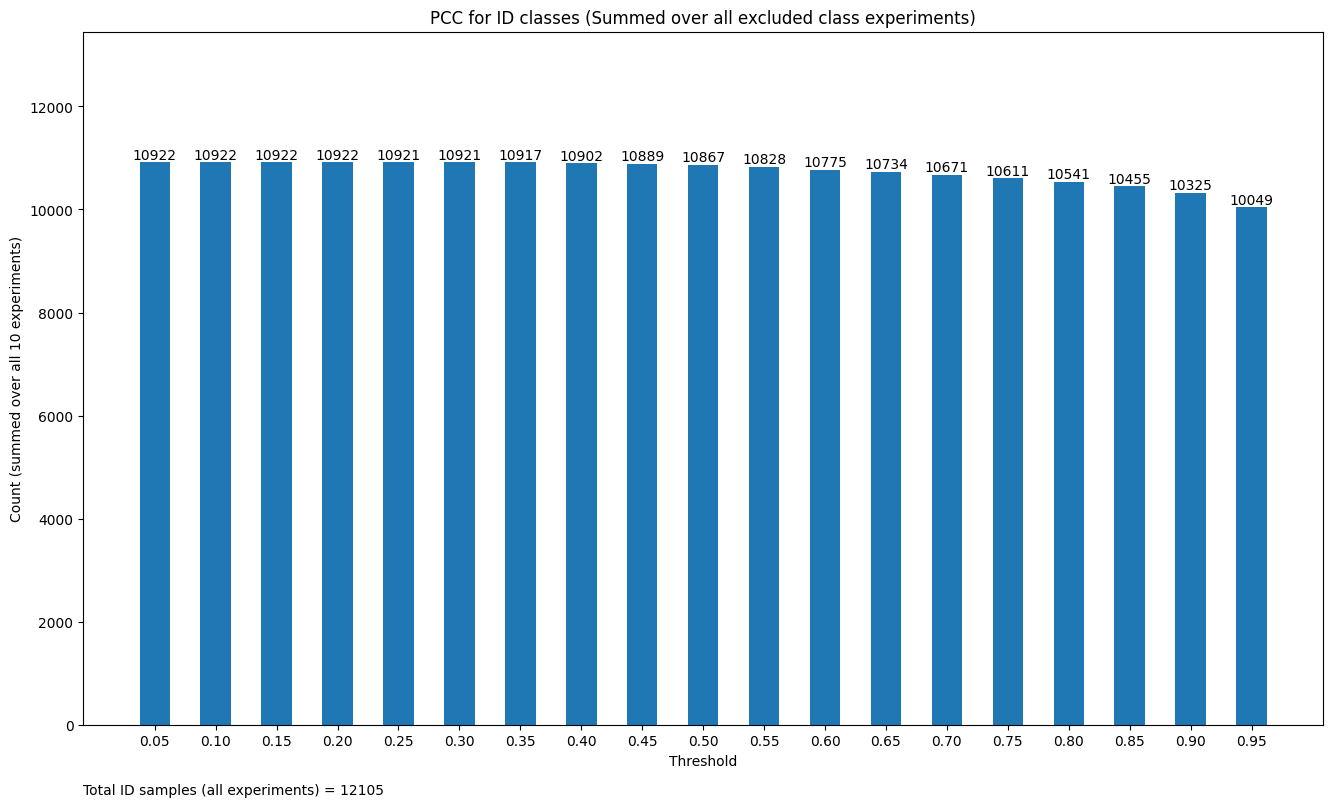

In [9]:
threshold = np.arange(0.05, 1.0, 0.05)
count_above_threshold_all = np.zeros(len(threshold), dtype=int)

for excluded_label in range(10):
    labels = label_full_flat[excluded_label]
    confidences = prob_full_flat[excluded_label]
    preds_og = pred_og_full_flat[excluded_label]

    for j, t in enumerate(threshold):
        correct_mask = (labels == preds_og)
        correct_conf = confidences[correct_mask]
        count_above_threshold_all[j] += np.sum(correct_conf >= t)

fig = plt.figure(figsize=(16, 9))
ax = fig.add_subplot(111)
ax.bar(threshold, count_above_threshold_all, width=0.025, align='center')
ax.set_xticks(threshold, [f"{t:.2f}" for t in threshold])

for i, count in enumerate(count_above_threshold_all):
    ax.text(threshold[i], count + 0.5, str(count), ha='center', va='bottom')

total_id = sum((label_full_flat[i] != i).sum() for i in range(10))
ax.text(0, -0.1, f"Total ID samples (all experiments) = {total_id}", transform=ax.transAxes)

ax.set_ylim(0, 13450)

ax.set_xlabel('Threshold')
ax.set_ylabel('Count (summed over all 10 experiments)')
ax.set_title('PCC for ID classes (Summed over all excluded class experiments)')
plt.show()

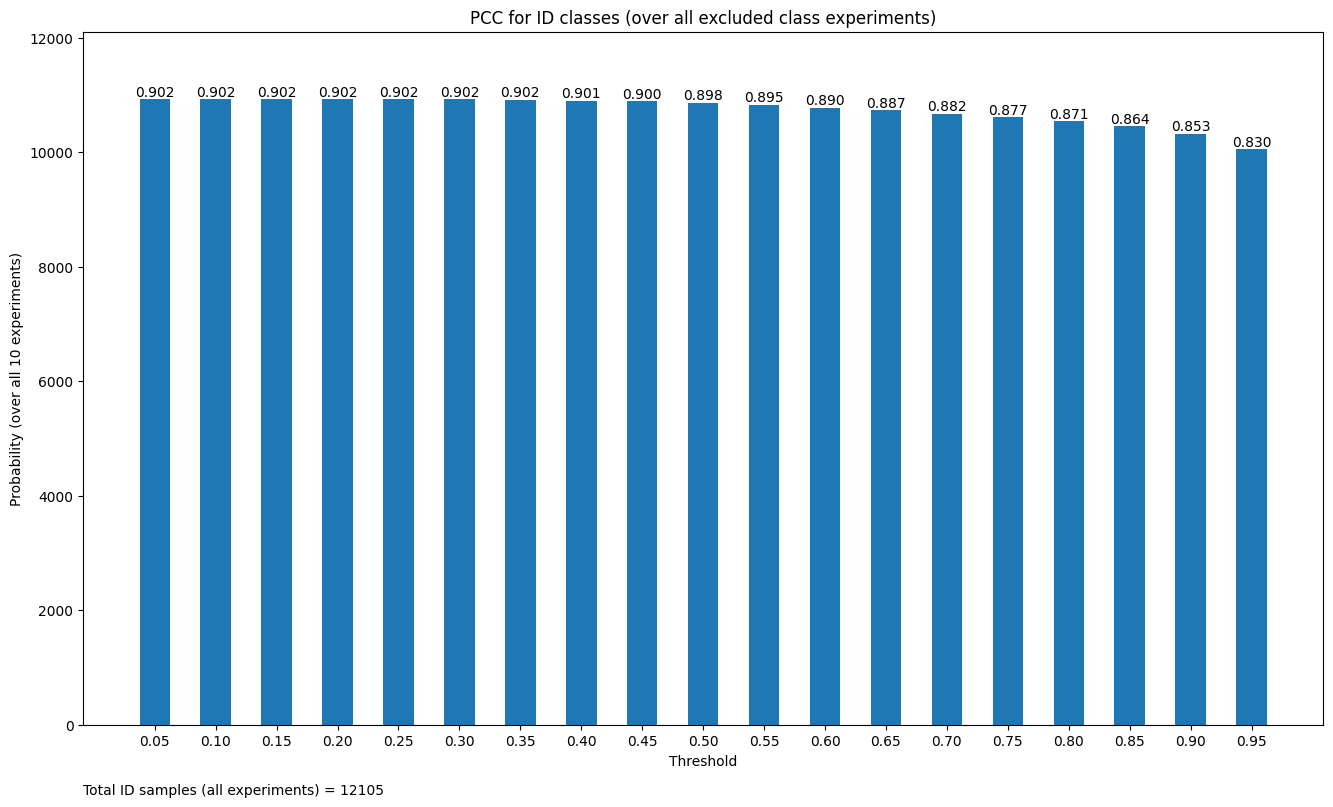

In [11]:
threshold = np.arange(0.05, 1.0, 0.05)
count_above_threshold_all = np.zeros(len(threshold), dtype=int)

for excluded_label in range(10):
    labels = label_full_flat[excluded_label]
    confidences = prob_full_flat[excluded_label]
    preds_og = pred_og_full_flat[excluded_label]

    for j, t in enumerate(threshold):
        correct_mask = (labels == preds_og)
        correct_conf = confidences[correct_mask]
        count_above_threshold_all[j] += np.sum(correct_conf >= t)

fig = plt.figure(figsize=(16, 9))
ax = fig.add_subplot(111)
ax.bar(threshold, count_above_threshold_all, width=0.025, align='center')
ax.set_xticks(threshold, [f"{t:.2f}" for t in threshold])

total_id = sum((label_full_flat[i] != i).sum() for i in range(10))

for i, count in enumerate(count_above_threshold_all):
    ax.text(threshold[i], count + 0.5, f"{count/total_id:.3f}", ha='center', va='bottom')

ax.text(0, -0.1, f"Total ID samples (all experiments) = {total_id}", transform=ax.transAxes)

ax.set_ylim(0, 12105)

ax.set_xlabel('Threshold')
ax.set_ylabel('Probability (over all 10 experiments)')
ax.set_title('PCC for ID classes (over all excluded class experiments)')
plt.show()

# wo aug

In [12]:
synth_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/synth"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

meas_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

In [13]:
label_full = []
prob_full = []
pred_og_full = []

for j in range(10):
    
    excluded_label = j
    excluded_label_name = synth_ds.classes[excluded_label]
    print(f"Excluding label {excluded_label} ({excluded_label_name}) from synthetic dataset")
    new_synth_ds = RemappedSubset(synth_ds, exclude_label=excluded_label)

    train_ds = new_synth_ds
    test_ds = meas_ds

    seed_lst = [42]

    label_lst = []
    prob_lst = []
    pred_lst = []

    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    for i, seed in enumerate(seed_lst):
        print(f"Evaluating Run {i}: seed {seed}")
        new_model = models.resnet18(weights = None) # dont load ImageNet Weights
        new_model.fc = nn.Sequential(
            nn.Dropout(p = 0.4),
            nn.Linear(new_model.fc.in_features, len(synth_ds.class_to_idx) - 1)
        )
        
        # Load your trained weights
        new_model.load_state_dict(torch.load(
            os.path.join(workspace, f"weights/SSR/OOD/wo_aug/rn18_seed{seed}_b16_rm_{excluded_label_name}.pth"),
            map_location=device
        ))
        
        new_model = new_model.to(device)
        new_model.eval()
        
        with torch.no_grad():
            for inputs, labels in DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=12, pin_memory=True, persistent_workers=True):
                inputs = inputs.to(device)
        
                outputs = new_model(inputs)
                probs = F.softmax(outputs, dim=1)
                confidence, preds = torch.max(probs, dim=1)
        
                prob_lst.append(confidence.cpu())
                pred_lst.append(preds.cpu())
                label_lst.append(labels)  # already on cpu from dataloader

    inv_label_map = {v: k for k, v in new_synth_ds.label_map.items()}

    preds_og = [
        inv_label_map[p.item()] for p in torch.cat(pred_lst)
    ]

    label_full.append(label_lst)
    prob_full.append(prob_lst)
    pred_og_full.append(preds_og)

label_full_flat = [torch.cat(l).numpy() for l in label_full]
prob_full_flat = [torch.cat(p).numpy() for p in prob_full]
pred_og_full_flat = [np.array(p) for p in pred_og_full]

Excluding label 0 (2s1) from synthetic dataset
Evaluating Run 0: seed 42
Excluding label 1 (bmp2) from synthetic dataset
Evaluating Run 0: seed 42
Excluding label 2 (btr70) from synthetic dataset
Evaluating Run 0: seed 42
Excluding label 3 (m1) from synthetic dataset
Evaluating Run 0: seed 42
Excluding label 4 (m2) from synthetic dataset
Evaluating Run 0: seed 42
Excluding label 5 (m35) from synthetic dataset
Evaluating Run 0: seed 42
Excluding label 6 (m548) from synthetic dataset
Evaluating Run 0: seed 42
Excluding label 7 (m60) from synthetic dataset
Evaluating Run 0: seed 42
Excluding label 8 (t72) from synthetic dataset
Evaluating Run 0: seed 42
Excluding label 9 (zsu23) from synthetic dataset
Evaluating Run 0: seed 42


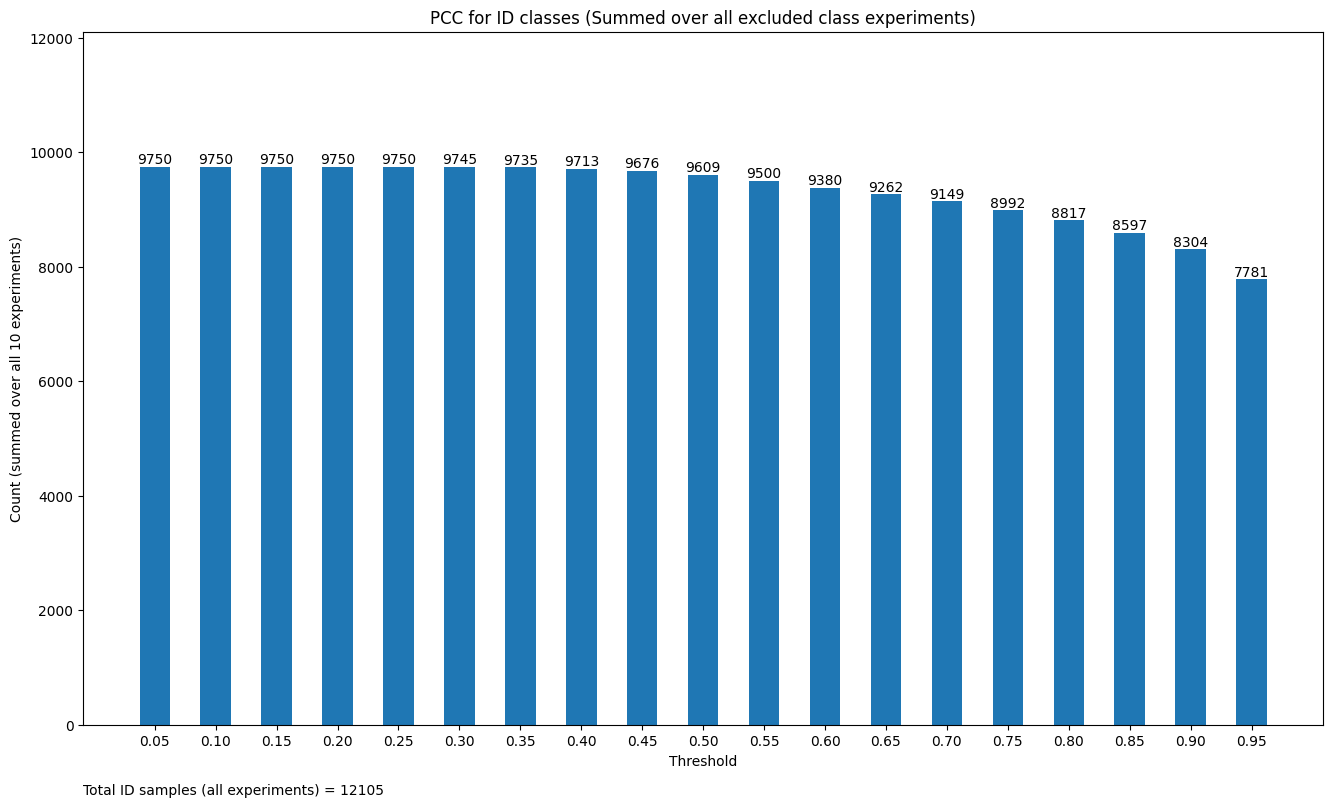

In [14]:
threshold = np.arange(0.05, 1.0, 0.05)
count_above_threshold_all = np.zeros(len(threshold), dtype=int)

for excluded_label in range(10):
    labels = label_full_flat[excluded_label]
    confidences = prob_full_flat[excluded_label]
    preds_og = pred_og_full_flat[excluded_label]

    for j, t in enumerate(threshold):
        correct_mask = (labels == preds_og)
        correct_conf = confidences[correct_mask]
        count_above_threshold_all[j] += np.sum(correct_conf >= t)

fig = plt.figure(figsize=(16, 9))
ax = fig.add_subplot(111)
ax.bar(threshold, count_above_threshold_all, width=0.025, align='center')
ax.set_xticks(threshold, [f"{t:.2f}" for t in threshold])

for i, count in enumerate(count_above_threshold_all):
    ax.text(threshold[i], count + 0.5, str(count), ha='center', va='bottom')

total_id = sum((label_full_flat[i] != i).sum() for i in range(10))
ax.text(0, -0.1, f"Total ID samples (all experiments) = {total_id}", transform=ax.transAxes)

ax.set_ylim(0, 12105)

ax.set_xlabel('Threshold')
ax.set_ylabel('Count (summed over all 10 experiments)')
ax.set_title('PCC for ID classes (Summed over all excluded class experiments)')
plt.show()

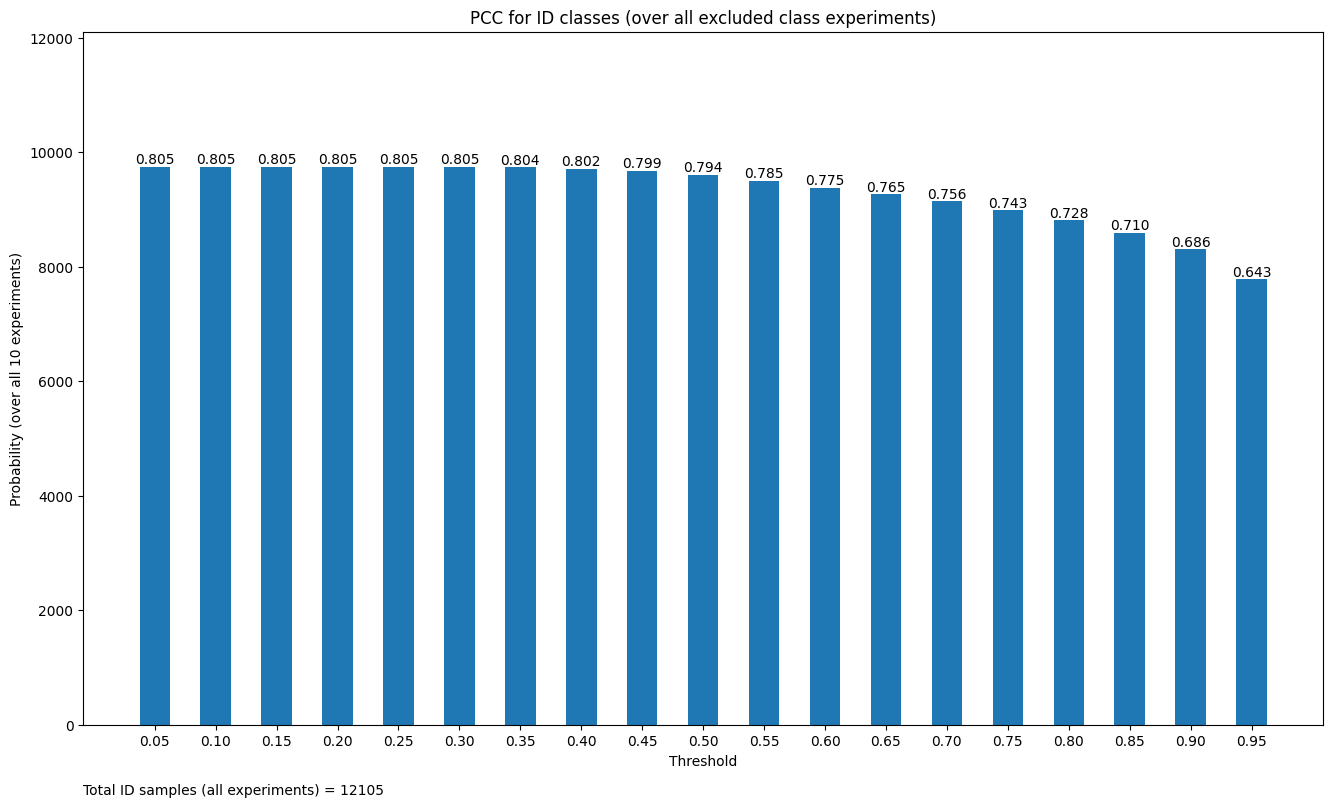

In [15]:
threshold = np.arange(0.05, 1.0, 0.05)
count_above_threshold_all = np.zeros(len(threshold), dtype=int)

for excluded_label in range(10):
    labels = label_full_flat[excluded_label]
    confidences = prob_full_flat[excluded_label]
    preds_og = pred_og_full_flat[excluded_label]

    for j, t in enumerate(threshold):
        correct_mask = (labels == preds_og)
        correct_conf = confidences[correct_mask]
        count_above_threshold_all[j] += np.sum(correct_conf >= t)

fig = plt.figure(figsize=(16, 9))
ax = fig.add_subplot(111)
ax.bar(threshold, count_above_threshold_all, width=0.025, align='center')
ax.set_xticks(threshold, [f"{t:.2f}" for t in threshold])

total_id = sum((label_full_flat[i] != i).sum() for i in range(10))

for i, count in enumerate(count_above_threshold_all):
    ax.text(threshold[i], count + 0.5, f"{count/total_id:.3f}", ha='center', va='bottom')

ax.text(0, -0.1, f"Total ID samples (all experiments) = {total_id}", transform=ax.transAxes)

ax.set_ylim(0, 12105)

ax.set_xlabel('Threshold')
ax.set_ylabel('Probability (over all 10 experiments)')
ax.set_title('PCC for ID classes (over all excluded class experiments)')
plt.show()